In [1]:
from pathlib import Path
from typing import Any

import numpy as np
from numpy.typing import NDArray
from tqdm import tqdm

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.images import argmax
import darksun as ds
from darksun.data import DataLoader, CatalogueLoader

import imgmaker as mgm

ds.show.set_figures_darkbkg()

In [2]:
def check_and_pick(parent: Path, pattern: str) -> Path:
    matches = tuple(parent.glob(pattern))
    if not matches:
        raise ValueError(f"A file matching the pattern {str(parent / pattern)} is expected but missing.")
    f, *extra_matches = matches
    if extra_matches:
        raise ValueError(
            f"Found unexpected extra matches for glob pattern {str(parent / pattern)}."
            f"File with pattern {pattern} should be unique"
        )
    return f

def inspect_srcphase(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    cat: CatalogueLoader,
    crp: tuple[int, int] = (40, 7),
    remove_srcs: list[str] | None = None,
) -> tuple[list[str], list[NDArray]]:
    """
    Extracts sources slice along the fine direction for phase investigation.
    """
    fine_slices: list[NDArray] = []

    src_list = cat.DLdata[(cat.DLdata['NAME'] != 'CXB')]  # NOTE: remove CXB
    src_ids = src_list['NAME']

    # retrieve pos for s0 and s1
    trg_src = src_list[src_list['NAME'] == 's0+0']
    det00 = count(camera, ds.select_source_photons(CoordEquatorial(trg_src['RA'], trg_src['DEC']), sdl.DLdata))[0]
    S0_POS = argmax(decode(camera, det00))

    trg_src = src_list[src_list['NAME'] == 's1+0']
    det10 = count(camera, ds.select_source_photons(CoordEquatorial(trg_src['RA'], trg_src['DEC']), sdl.DLdata))[0]
    S1_POS = argmax(decode(camera, det10))

    get_pos = lambda srcID: S0_POS if 's0' in srcID else S1_POS   

    # remove unwanted srcs
    if remove_srcs is not None:
        rmsrc = np.ones(len(src_ids), dtype=bool)
        for s in remove_srcs:
            rmsrc &= (src_ids != s)

        src_ids = src_ids[rmsrc]
    
    # loop on remaining srcs
    src_loop = tqdm(src_ids, desc='Source Analysis')
    for srcID in src_loop:
        src_loop.set_postfix({'S': f'{srcID}'})

        rmsrc = (src_list['NAME'] != srcID)
        exclude_coords: list[CoordEquatorial] = [
            CoordEquatorial(ra, dec) for ra, dec in zip(src_list[rmsrc]['RA'], src_list[rmsrc]['DEC'])
        ]
        phs = ds.filter_data(sdl.DLdata, E_min=None, E_max=None, coords=exclude_coords)

        detector, _ = count(camera, phs)
        skymap = decode(camera, detector)
        crpmap = ds.crop(skymap, pos=get_pos(srcID), crp=crp)

        xslice, yslice = crpmap[crp[0], :], crpmap[:, crp[1]]
        fine_slices.append(xslice)

    return src_ids, fine_slices

In [3]:
dirpath: str = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'

MASK_FITS: str = f"{dirpath}/mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 1, 1

SKYFIELD: str = "CameraGeometry"
DATA_FITS: str = Path(f"{dirpath}/{SKYFIELD}/src_phase")

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

VIGNETTING: bool = True
PSFY: bool = mgm.config_psfy_flag(DATASET)

E_min, E_max = 2.0, 50.0           # [keV]

In [4]:
wfm: CodedMaskCamera = codedmask(MASK_FITS, UPS_X, UPS_Y)
sdlA = ds.get_data(
    check_and_pick(DATA_FITS, f'{ID_CAMERA_A}/*{DATASET}*.fits'), E_min=E_min, E_max=E_max,
)
catA = ds.get_catalogue(check_and_pick(DATA_FITS, f'{ID_CAMERA_A}/*sources*.fits'))

In [5]:
remove_srcs = ['s0-3', 's0+3', 's1-3', 's1+3']
remove_srcs = None
src_ids, fine_slices = inspect_srcphase(wfm, sdlA, catA, crp=(40, UPS_X + 2), remove_srcs=remove_srcs)

CATALOG ='src_phase_catalogue_2-50keV.fits' / Catalog file                       [astropy.io.fits.card]


Selected 181975/2833445 photons.
Selected 155749/2833445 photons.


Source Analysis: 100%|██████████| 14/14 [00:12<00:00,  1.13it/s, S=s1+3]


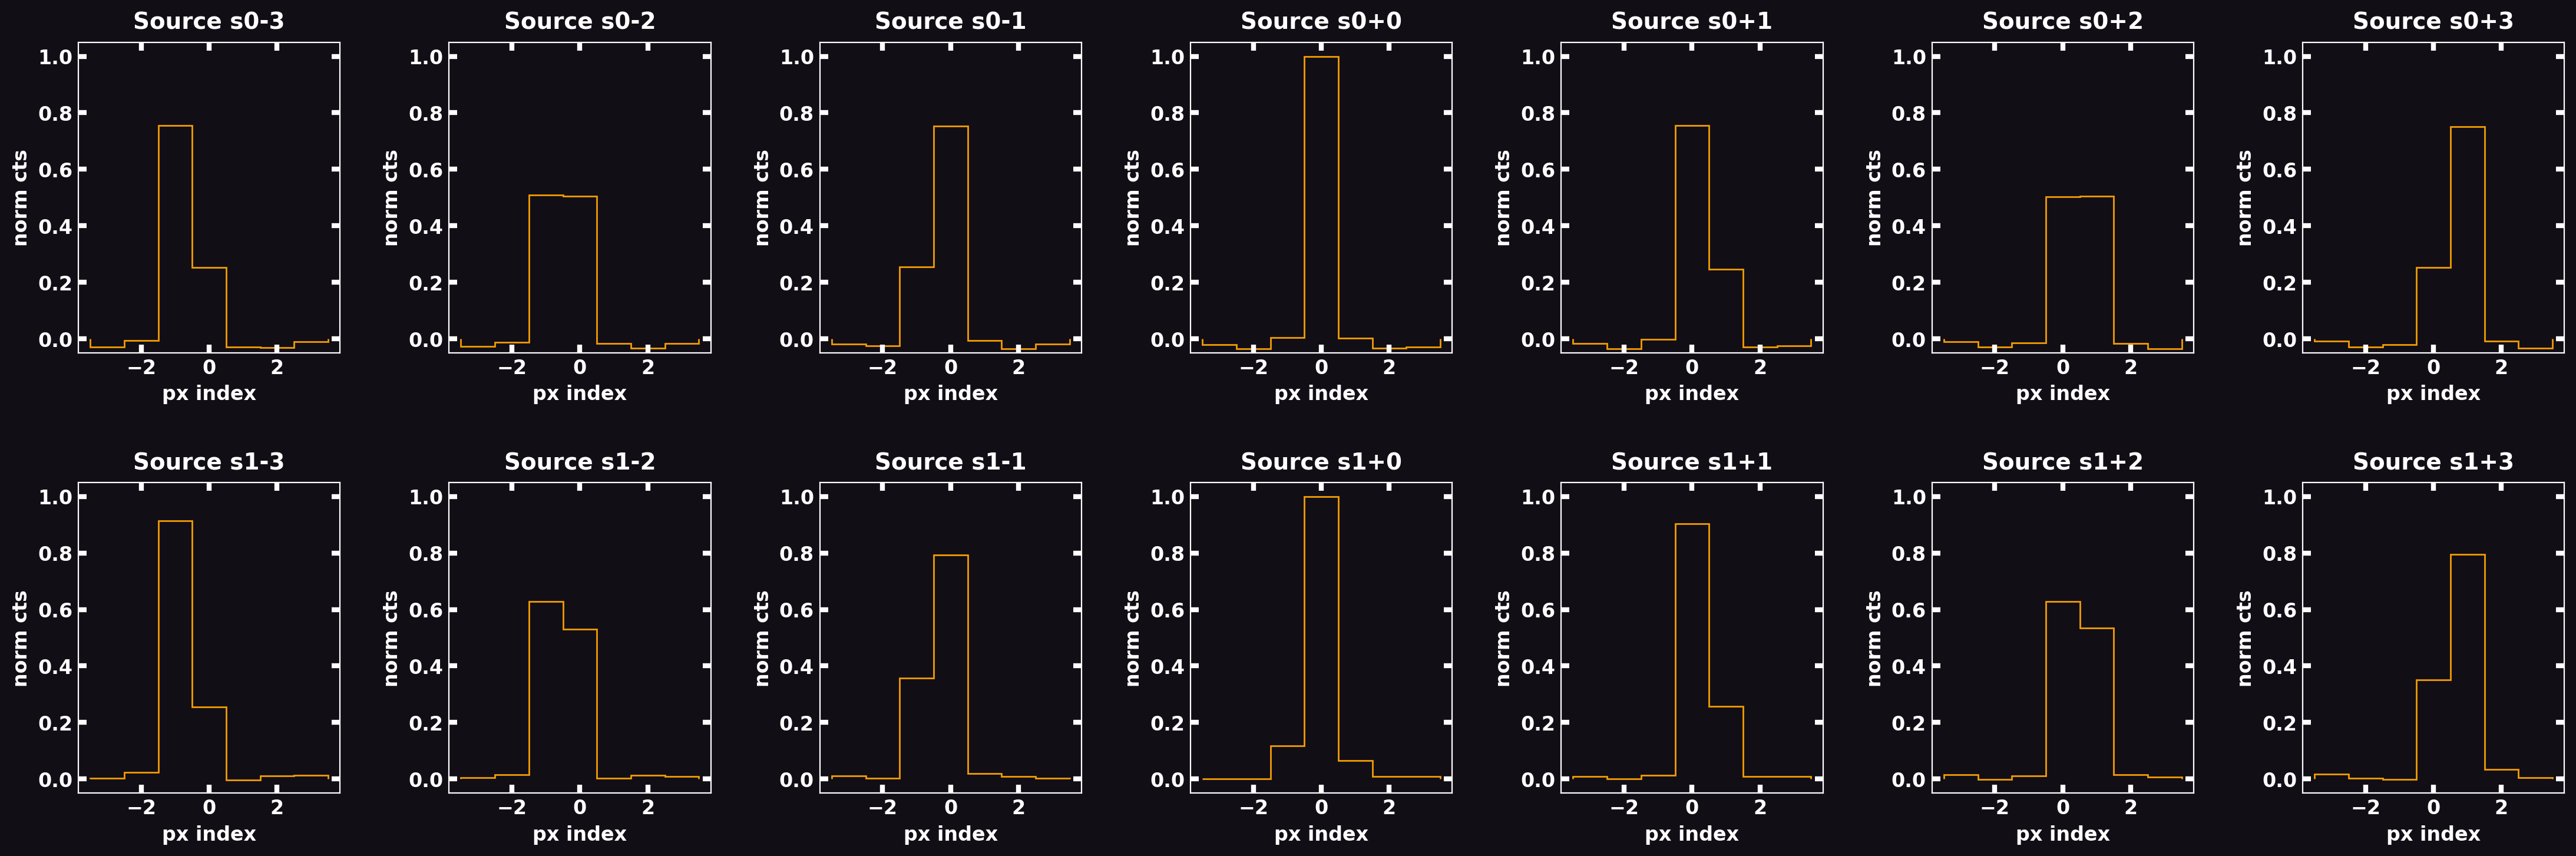

In [6]:
def get_phase(x: NDArray) -> NDArray:
    """Centers x-axis values around zero."""
    return np.arange(len(x) + 1) - len(x) // 2 - 0.5

_idx00, _idx10 = np.arange(len(fine_slices))[:: len(fine_slices) // 2] + len(fine_slices) // 4
_up_to: int = len(fine_slices) // 2

_s00max, _s10max = map(np.max, (fine_slices[_idx00], fine_slices[_idx10]))
norm = np.array([_s00max] * (len(fine_slices) // 2) + [_s10max] * (len(fine_slices) // 2))
get_dmap = lambda x, title: ds.map4plot(
    x, title, style='stairs', x=get_phase(x), color='Orange', ylim=(-5e-2, 1 + 5e-2), ylabel='norm cts', xlabel='px index',
)

ds.plot(
    dmaps=tuple(get_dmap(xslice, f'Source {srcID}') for srcID, xslice in zip(src_ids, fine_slices / norm[:, None])),
    ncols=_up_to,
    nrows=2,
    size=3,
)

In [ ]:
def cycle_through_ups(
    ups: list[int],
    sdl: DataLoader,
    cat: CatalogueLoader,
    remove_srcs: list[str] | None = None,
) -> dict[int, NDArray]:
    """
    Cycles through given mask array upsampling along the
    fine direction and extracts PSF slice max values.
    """
    ups_phase: dict[int, NDArray] = {}
    _srcs = len(cat.DLdata['NAME']) - 1 - (len(remove_srcs) if remove_srcs else 0)
    _idx00, _idx10 = np.arange(_srcs)[:: _srcs // 2] + _srcs // 4

    for up in ups:
        print(f'## Analysing upscaling: {up}')
        wfm_cycle: CodedMaskCamera = codedmask(MASK_FITS, up, 1)
        _, fine_slices = inspect_srcphase(wfm_cycle, sdl, cat, crp=(40, UPS_X + 2), remove_srcs=remove_srcs)
        _s00max, _s10max = map(np.max, (fine_slices[_idx00], fine_slices[_idx10]))
        norm = np.array([_s00max] * (len(fine_slices) // 2) + [_s10max] * (len(fine_slices) // 2))
        ups_phase[up] = np.array([float(np.round(arr.max(), decimals=3)) for arr in fine_slices / norm[:, None]])
    
    return ups_phase

In [15]:
ups: list[int] = list(range(1, 6))
# remove_srcs = ['s0-3', 's0+3', 's1-3', 's1+3']
remove_srcs = None

dmap_ups = cycle_through_ups(ups, sdlA, catA, remove_srcs=remove_srcs)

Analysing upscaling: 1
Selected 181975/2833445 photons.
Selected 155749/2833445 photons.


Source Analysis: 100%|██████████| 14/14 [00:11<00:00,  1.21it/s, S=s1+3]


Analysing upscaling: 2
Selected 181975/2833445 photons.
Selected 155749/2833445 photons.


Source Analysis: 100%|██████████| 14/14 [00:11<00:00,  1.17it/s, S=s1+3]


Analysing upscaling: 3
Selected 181975/2833445 photons.
Selected 155749/2833445 photons.


Source Analysis: 100%|██████████| 14/14 [00:12<00:00,  1.13it/s, S=s1+3]


Analysing upscaling: 4
Selected 181975/2833445 photons.
Selected 155749/2833445 photons.


Source Analysis: 100%|██████████| 14/14 [00:13<00:00,  1.06it/s, S=s1+3]


Analysing upscaling: 5
Selected 181975/2833445 photons.
Selected 155749/2833445 photons.


Source Analysis: 100%|██████████| 14/14 [00:13<00:00,  1.01it/s, S=s1+3]


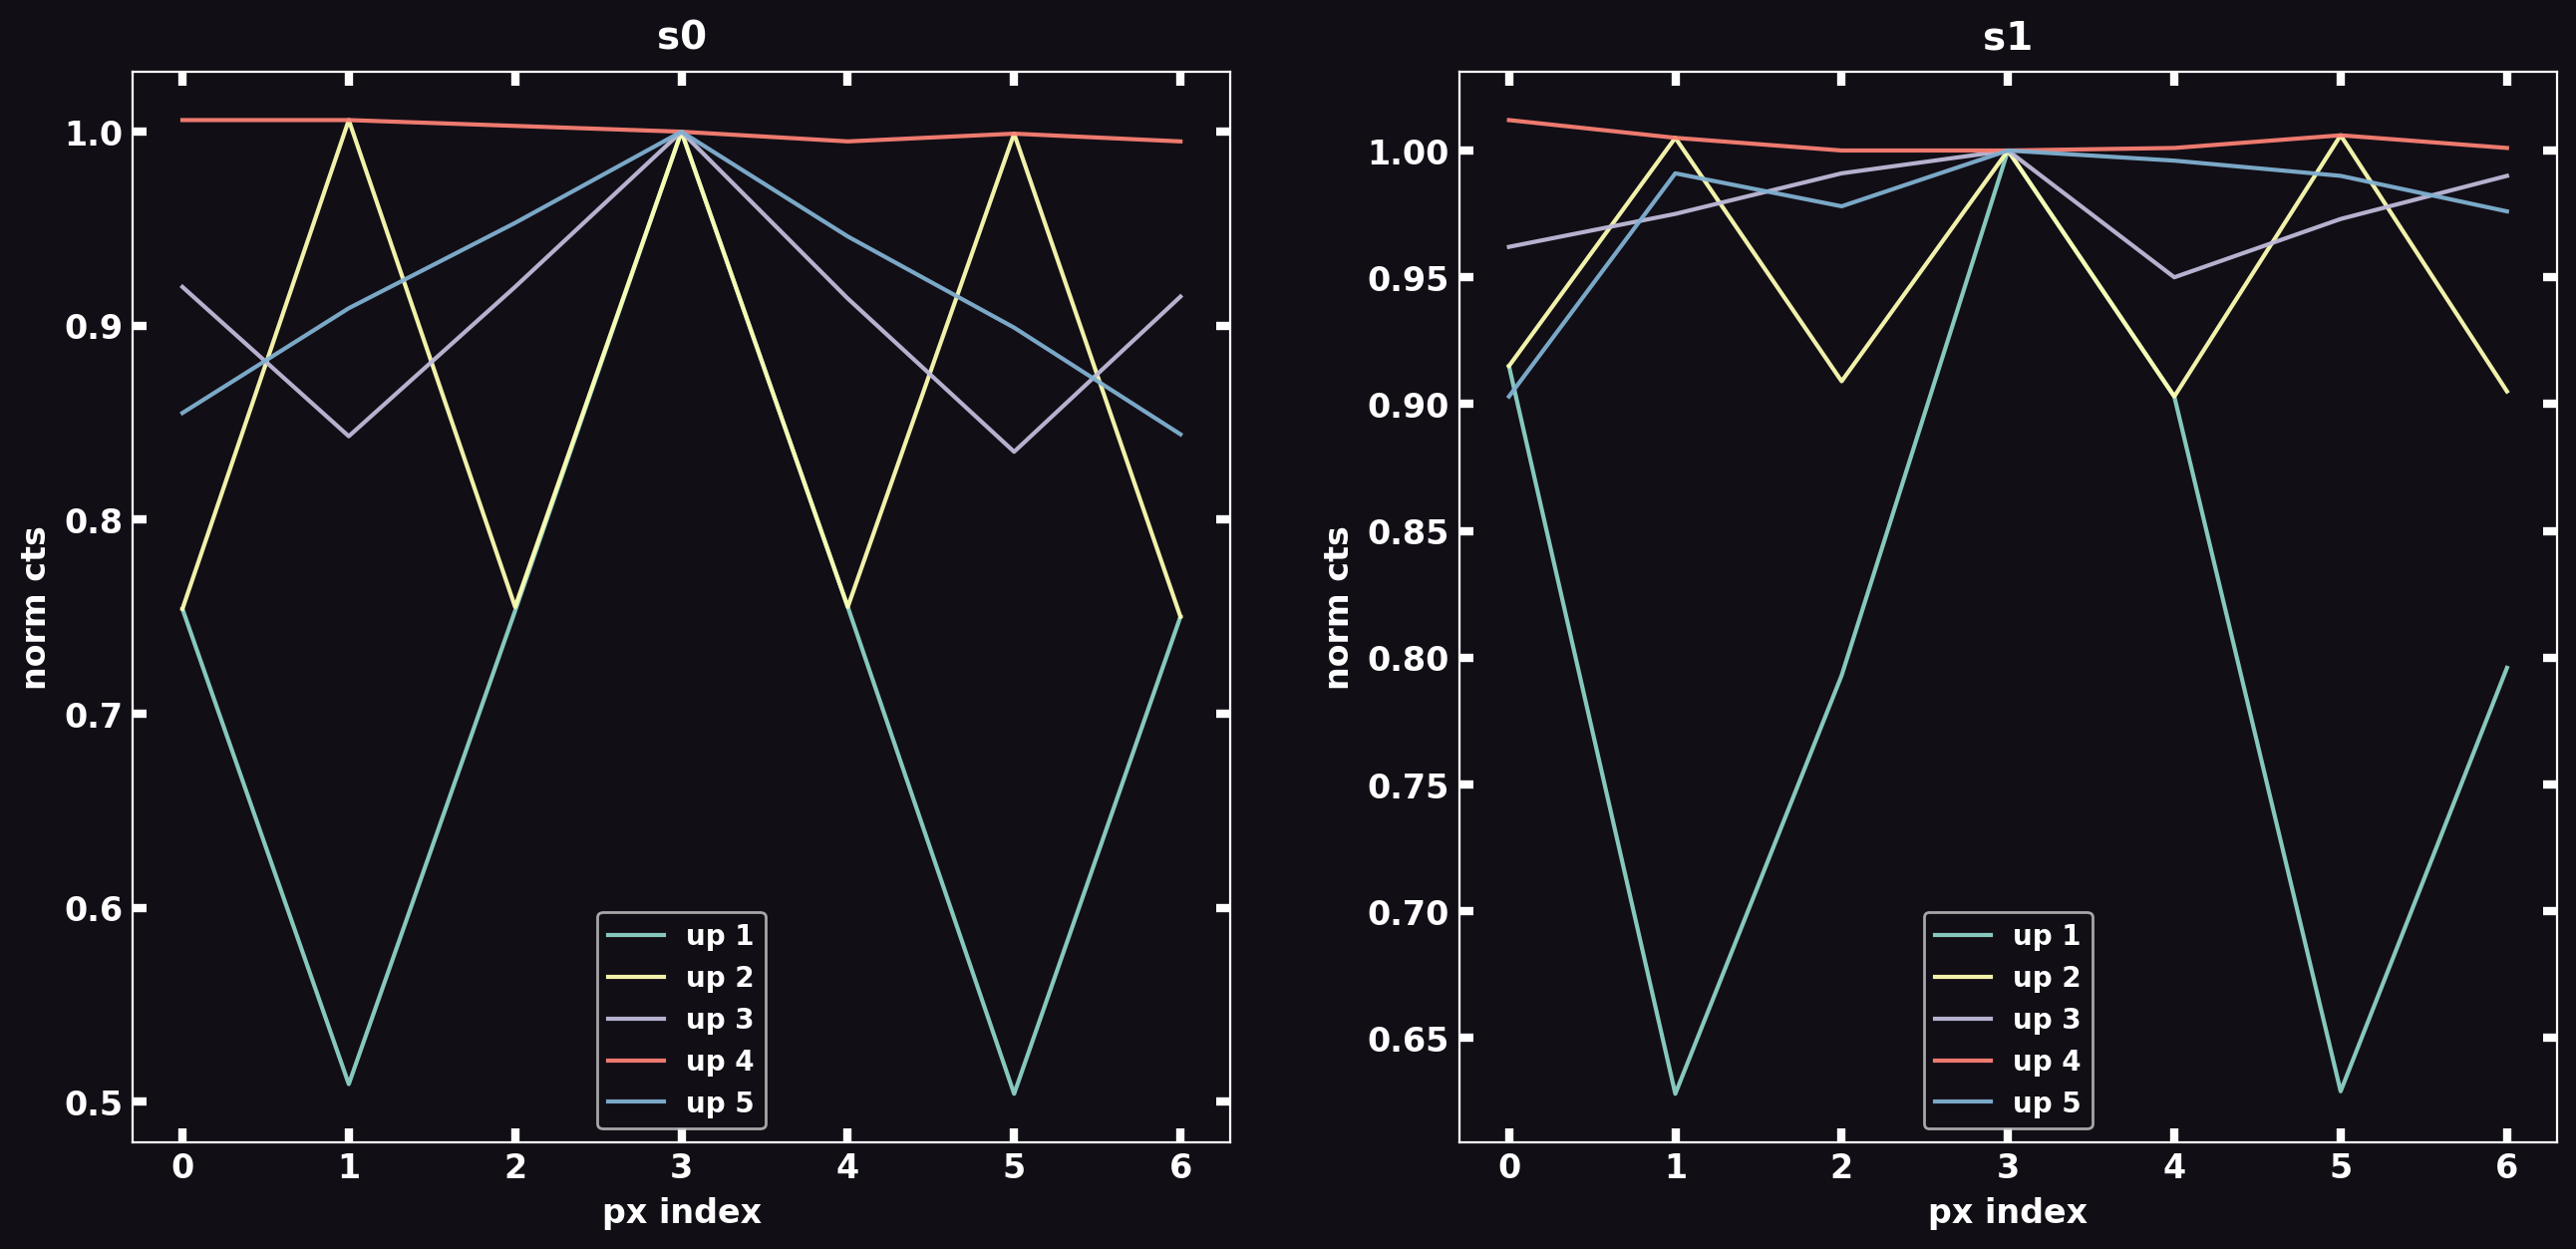

In [18]:
_up_to = len(dmap_ups[1]) // 2
s00_vals, s01vals = zip(
    *tuple((xslice[:_up_to], xslice[_up_to:]) for xslice in dmap_ups.values())
)
lbls = tuple(f'up {up}' for up in dmap_ups.keys())

ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=s00_vals,
            title='s0',
            ylabel='norm cts',
            xlabel='px index',
            labels=lbls,
        ),
        ds.map4plot(
            arrs=s01vals,
            title='s1',
            ylabel='norm cts',
            xlabel='px index',
            labels=lbls,
        ),
    ),
    ncols=2,
)

In [ ]:
import matplotlib.pyplot as plt
from bloodmoon.coords import shift2angle


pos: list[tuple[float, float]] = [
    (-35.0, -35.0), (-35.0, 35.0), (35.0, 35.0), (35.0, -35.0),
    (-15.0, -15.0), (-15.0, 15.0), (15.0, 15.0), (15.0, -15.0),
    (0.0, 0.0),
]

def show_skygrid(
    camera: CodedMaskCamera,
    pos: list[tuple[float, float]],
    save_to: str | Path | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    _skyx, _skyy = camera.bins_sky
    skyx, skyy = map(
        lambda x: shift2angle(camera, x),
        (_skyx, _skyy),
    )
    
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)

    ax.plot((skyx[0], skyx[-1]), (0, 0), color='Red', linestyle='-', linewidth=0.6, alpha=0.3)
    ax.plot((0, 0), (skyy[0], skyy[-1]), (0, 0), color='Red', linestyle='-', linewidth=0.6, alpha=0.3)
    for idx, p in enumerate(pos):
        ax.scatter(p[0], p[1], marker='+', facecolor='DodgerBlue', alpha=0.8, s=30)
        ax.text(p[1] + 1, p[0] + 1, f'S{idx}', color='k', rotation=0, fontsize=10)
        crds = f'({int(p[1])}, {int(p[0])})'
        ax.text(p[1] - len(crds) / 2, p[0] - 5, crds, color='k', rotation=0, fontsize=8)

    ax.set_xlim(skyx[0], skyx[-1]); ax.set_ylim(skyy[0], skyy[-1])
    ax.set_xlabel(xlabel='$\\theta_{\\text{X}}$ [deg]')
    ax.set_ylabel(ylabel='$\\theta_{\\text{Y}}$ [deg]')
    ax.xaxis.set_ticks_position('both'); ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    return


show_skygrid(wfm, pos, save_to="/home/edoardo/Desktop/skygrid.pdf", figsize=(4.5, 4.0))

In [16]:
GEN_CATALOGUE: bool = False

assert GEN_CATALOGUE

AssertionError: 

In [ ]:
from typing import NamedTuple
from dataclasses import dataclass
from numpy.typing import NDArray
from bloodmoon.types import CoordEquatorial

class Source(NamedTuple):
    """Source info container."""
    ID: str             
    shift_x: float  # [mm]
    shift_y: float  # [mm]
    flx: float      # [Crab]

class CatalogueEntry(NamedTuple):
    """Catalogue entries data for mock sources."""
    ID: str
    name: str
    ra: float
    dec: float
    avg_flux: float
    code: int
    formula: str
    index: float
    nh: float
    energy: NDArray
    spectrum: NDArray

@dataclass(frozen=True)
class CameraPointer:
    """Instance with LEM-X coded-mask cameras pointings."""
    CAMZRA: float
    CAMZDEC: float
    CAMXRA: float
    CAMXDEC: float

    @property
    def pointings(self) -> dict[str, CoordEquatorial]:
        """
        Camera axis pointing information in equatorial frame.
        Angles are expressed in degrees.
        """
        return {
            "z": CoordEquatorial(ra=self.CAMZRA, dec=self.CAMZDEC),
            "x": CoordEquatorial(ra=self.CAMXRA, dec=self.CAMXDEC),
        }

def get_pointings(
    z_axis_RA: float = 266.4,
    z_axis_DEC: float = -28.94,
    x_axis_RA: float = 266.4,
    x_axis_DEC: float = 61.06,
) -> CameraPointer:
    """Defines LEM-X Unit pointings. Default to std directions."""
    return CameraPointer(
        z_axis_RA, z_axis_DEC, x_axis_RA, x_axis_DEC,
    )

In [ ]:
import numpy as np
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.coords import angle2shift

def get_intshifts(
    camera: CodedMaskCamera,
    angle_x: float,
    angle_y: float,
) -> tuple[float, float]:
    """Computes the closest integer shift coords in [mm] wrt input angural coords."""
    sx, sy = map(lambda x: angle2shift(camera, x), (angle_x, angle_y))
    int_shifts = (
        float(np.round(sx / camera.specs.mask_deltax) * camera.specs.mask_deltax),
        float(np.round(sy / camera.specs.mask_deltay) * camera.specs.mask_deltay),
    )
    return int_shifts

def get_src_phase(
    camera: CodedMaskCamera,
    centre: tuple[float, float],
    step: tuple[float, float],
    extension: int = 3,
) -> list[tuple[float, float]]:
    """
    Creates a list of coords following the given binning phase step.
    The coords (fine, coarse) are in [mm], and centered around `centre` with given `step`.
    """
    phase_x, phase_y = (
        np.arange(-extension, extension + 1) * camera.specs.mask_deltax * step[0] + centre[0],
        np.arange(-extension, extension + 1) * camera.specs.mask_deltay * step[1] + centre[1],
    )
    return [(float(sx), float(sy)) for sx, sy in zip(phase_x, phase_y)]

def get_srcs(
    camera: CodedMaskCamera,
    coords: list[tuple[float, float]],
    flxs: list[float],
    step: tuple[float, float] = (0.25, 0.0),
    extension: int = 3,
) -> list[Source]:
    """Returns list of sources with IDs and data."""
    srcs: list[Source] = []

    for idx, (tx, ty) in enumerate(coords):
        shifts_phase = get_src_phase(camera, get_intshifts(camera, tx, ty), step=step, extension=extension)
        nphase = np.arange(len(shifts_phase), dtype=int) - len(shifts_phase) // 2
        src_phase = [
            Source(f's{idx}{'+' if np.sign(phase) + 1 else '-'}{abs(phase)}', sx, sy, flxs[idx])
            for phase, (sx, sy) in zip(nphase, shifts_phase)
        ]
        srcs += src_phase
    
    return srcs

In [ ]:
from pathlib import Path
from astropy.table import Table
from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec
from bloodmoon.coords import shift2equatorial


def load_fits_data(path: Path, ext: int = 1) -> FITS_rec:
    """Loads the FITS file data from chosen extension."""
    return fits.getdata(path, ext=ext, header=False)


def gen_table(
    srcs: list[Source],
    camera: CodedMaskCamera,
    sdl: CameraPointer,
    spectr_info: FITS_rec,
) -> Table:
    """Generates the tabular data for input sources."""
    entries: list[CatalogueEntry] = []
    _flags = ('code', 'formula', 'index', 'nh', 'energy')
    flags = {key: spectr_info[key.upper()][0] for key in _flags}
    for src in srcs:
        ra, dec = shift2equatorial(sdl, camera, src.shift_x, src.shift_y)
        entry = CatalogueEntry(
            ID=src.ID,
            name=src.ID,
            ra=ra,
            dec=dec,
            avg_flux=spectr_info['AVG_FLUX'][0] * src.flx,
            spectrum=spectr_info['SPECTRUM'][0] * src.flx,
            **flags,
        )
        entries.append(entry)
    
    record = np.rec.array(
        obj=entries,
        dtype=[
            ('ID', '16U'), ('NAME', '20U'), ('RA', np.float32), ('DEC', np.float32), ('AVG_FLUX', np.float32),
            ('CODE', np.uint8), ('FORMULA', '16U'), ('INDEX', np.float32), ('NH', np.float32),
            ('ENERGY', np.float32, 513), ('SPECTRUM', np.float32, 512),
        ],
    )
    table: Table = Table(
        data=record,
        units=('', '', 'deg', 'deg', 'ph.s-1.cm-2', '', '', '', '', 'keV', 'ph.s-1.cm-2.keV-1'),
    )
    return table
        

def save_table(data: Table, save_to: str | Path) -> None:
    """Saves tabular catalogue to FITS file."""
    print("# Saving data...")
    # HDU list and Primary Header
    hdu_list = fits.HDUList([])
    primary_hdu = fits.PrimaryHDU()
    hdu_list.append(primary_hdu)
    # BinTable
    table_hdu = fits.BinTableHDU(
        data=data,
        name='SOURCES',
    )
    hdu_list.append(table_hdu)
    # save data
    hdu_list.writeto(save_to, output_verify="fix+ignore")
    hdu_list.close()
    print("# Saving completed!")
    return None

In [ ]:
from bloodmoon.mask import codedmask

dirpath: str = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
MASK_FITS: str = f"{dirpath}/mask_NTHT_20260129_CORRECTED.fits"
wfm: CodedMaskCamera = codedmask(MASK_FITS)
sdl: CameraPointer = get_pointings()

crab_spectr: FITS_rec = load_fits_data(f"{dirpath}/crab_spectrum_2-50keV.fits")

In [ ]:
srcs: list[Source] = get_srcs(
    camera=wfm,
    coords=[(0.0, 0.0), (20.0, 20.0)],
    flxs=[1.0, 1.5],
)

srcs

[Source(ID='s0-3', shift_x=-0.1875, shift_y=0.0, flx=1.0),
 Source(ID='s0-2', shift_x=-0.125, shift_y=0.0, flx=1.0),
 Source(ID='s0-1', shift_x=-0.0625, shift_y=0.0, flx=1.0),
 Source(ID='s0+0', shift_x=0.0, shift_y=0.0, flx=1.0),
 Source(ID='s0+1', shift_x=0.0625, shift_y=0.0, flx=1.0),
 Source(ID='s0+2', shift_x=0.125, shift_y=0.0, flx=1.0),
 Source(ID='s0+3', shift_x=0.1875, shift_y=0.0, flx=1.0),
 Source(ID='s1-3', shift_x=73.8125, shift_y=74.0, flx=1.5),
 Source(ID='s1-2', shift_x=73.875, shift_y=74.0, flx=1.5),
 Source(ID='s1-1', shift_x=73.9375, shift_y=74.0, flx=1.5),
 Source(ID='s1+0', shift_x=74.0, shift_y=74.0, flx=1.5),
 Source(ID='s1+1', shift_x=74.0625, shift_y=74.0, flx=1.5),
 Source(ID='s1+2', shift_x=74.125, shift_y=74.0, flx=1.5),
 Source(ID='s1+3', shift_x=74.1875, shift_y=74.0, flx=1.5)]

In [ ]:
table: Table = gen_table(srcs, wfm, sdl, crab_spectr)

table

ID,NAME,RA,DEC,AVG_FLUX,CODE,FORMULA,INDEX,NH,ENERGY,SPECTRUM
,,deg,deg,ph / (s cm2),,,,,keV,ph / (keV s cm2)
str16,str20,float32,float32,float32,uint8,str16,float32,float32,float32[513],float32[512]
s0-3,s0-3,266.4,-28.992908,4.548662,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,2.3097186 .. 0.0034760905
s0-2,s0-2,266.4,-28.975271,4.548662,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,2.3097186 .. 0.0034760905
s0-1,s0-1,266.4,-28.957636,4.548662,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,2.3097186 .. 0.0034760905
s0+0,s0+0,266.4,-28.94,4.548662,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,2.3097186 .. 0.0034760905
s0+1,s0+1,266.4,-28.922363,4.548662,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,2.3097186 .. 0.0034760905
s0+2,s0+2,266.4,-28.904728,4.548662,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,2.3097186 .. 0.0034760905
s0+3,s0+3,266.4,-28.887093,4.548662,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,2.3097186 .. 0.0034760905
s1-3,s1-3,247.27615,-8.4755945,6.8229933,1,tbabs*powerlaw,2.05,0.3,2.0 .. 50.0,3.464578 .. 0.0052141356


In [ ]:
import darksun as ds

SAVE_CATALOGUE: bool = True

if SAVE_CATALOGUE:
    save_table(table, ds.savefile_to(dirpath, 'src_phase_catalogue_2-50keV', frmt='fits'))

# Saving data...
# Saving completed!
